In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder

### Gaussian NB

In [3]:
gaussian_df_noShale = pd.read_csv("data/nb/gnb_data.csv")

# Train test splitting
Training_G, Testing_G = train_test_split(gaussian_df_noShale, test_size=.2)

Training_G_Label = Training_G["LITHOLOGY"]
Training_G=Training_G.drop(["LITHOLOGY"], axis=1)

Testing_G_Label = Testing_G["LITHOLOGY"]
Testing_G = Testing_G.drop(["LITHOLOGY"], axis=1)

display(Training_G.head(3))
display(Testing_G_Label.head(3))

,CALI,RHOB,NPHI,DTC
10507,13.039060,2.519819,0.280306,97.335869
9270,8.666450,2.556056,0.118605,83.342430
2705,8.958001,2.524651,0.179949,78.907486


10097         Sandstone
5880     SandstoneShale
7405     SandstoneShale
Name: LITHOLOGY, dtype: object

In [4]:
# Fitting
from sklearn.naive_bayes import GaussianNB
# Create Gaussian Naive Bayes model
MyGNB = GaussianNB()
# Fit the model on the training data
MyGNB_Model = MyGNB.fit(Training_G, Training_G_Label)

# Predict the Testing Data using the model
Predictions_G = MyGNB_Model.predict(Testing_G)
print(Predictions_G[:5])

['Sandstone' 'Sandstone' 'Limestone' 'Chalk' 'Chalk']


In [5]:
## Print the probabilities
## Recall that Naive Bayes calculates the probability of each label even though it only predicts the largest of those probabilities.
## Knowing the probabilities of each label will help you to see how "certain" (or not) the model was about its prediction.
print("The Gaussian NB Model Prediction Probabilities are:")
print(MyGNB_Model.predict_proba(Testing_G).round(3))

The Gaussian NB Model Prediction Probabilities are:
[[0.    0.013 0.    ... 0.796 0.151 0.02 ]
 [0.    0.002 0.    ... 0.608 0.313 0.   ]
 [0.001 0.    0.    ... 0.241 0.213 0.   ]
 ...
 [0.698 0.    0.    ... 0.064 0.026 0.   ]
 [0.049 0.    0.    ... 0.196 0.106 0.   ]
 [0.    0.001 0.    ... 0.641 0.286 0.   ]]


In [40]:
# Calculate the accuracy of the model
gnb_accuracy = MyGNB_Model.score(Testing_G, Testing_G_Label)
print("The accuracy of the Gaussian Naive Bayes model is: ", gnb_accuracy)

The accuracy of the Gaussian Naive Bayes model is:  0.5534883720930233


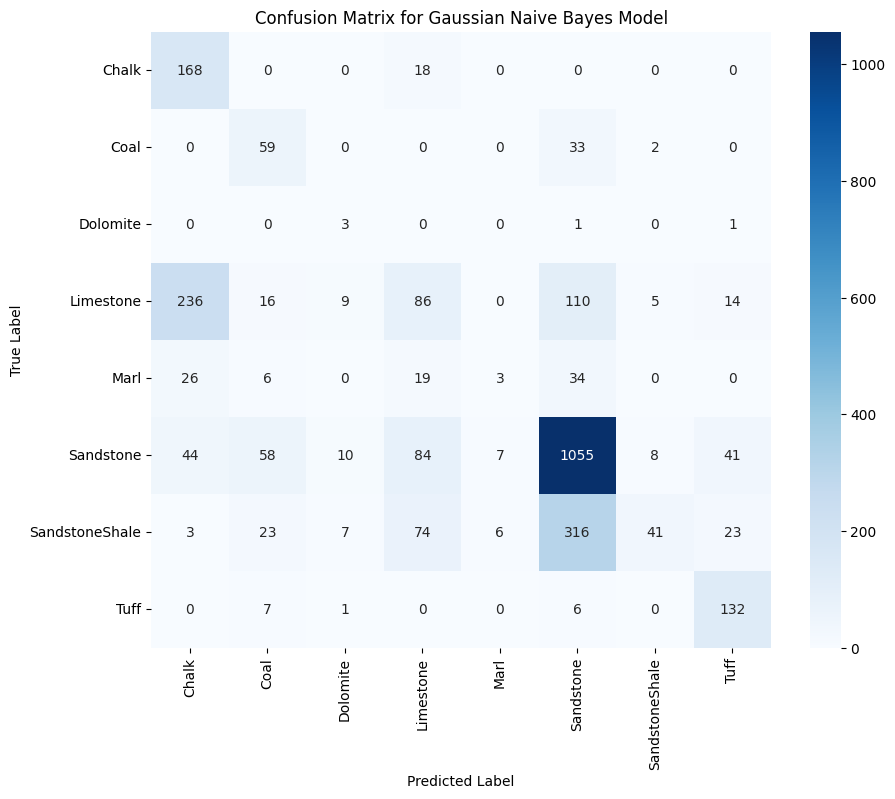

In [6]:
# Plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Create confusion matrix
cm = confusion_matrix(Testing_G_Label, Predictions_G, labels=MyGNB_Model.classes_)
# Plotting the confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=MyGNB_Model.classes_,
            yticklabels=MyGNB_Model.classes_)
plt.title('Confusion Matrix for Gaussian Naive Bayes Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Categorical NB

In [7]:
categorical_df = pd.read_csv("data/nb/cnb_data.csv")

Training_C, Testing_C = train_test_split(categorical_df, test_size=.2)

# Train test splitting
Training_C_Label = Training_C["LITHOLOGY"]
Training_C=Training_C.drop(["LITHOLOGY"], axis=1)
Testing_C_Label = Testing_C["LITHOLOGY"]
Testing_C=Testing_C.drop(["LITHOLOGY"], axis=1)

display(Testing_C.head(3))
Testing_C_Label.head(3)

,CALI,RHOB,NPHI,DTC
1613,1.0,2.0,0.0,0.0
8775,0.0,1.0,0.0,1.0
7478,0.0,2.0,0.0,0.0


1613        Chalk
8775    Sandstone
7478    Sandstone
Name: LITHOLOGY, dtype: object

In [8]:
from sklearn.naive_bayes import CategoricalNB

MyCNB = CategoricalNB()

# Fit the model
My_CNB_Model = MyCNB.fit(Training_C, Training_C_Label)

# Predict the Testing Data using the model
Predictions_C=My_CNB_Model.predict(Testing_C)
print("First 5 predicted values: ", Predictions_C[:5])

# Print the actual probabilities
print("\nThe Categorical NB Model Prediction Probabilities are:")
print(My_CNB_Model.predict_proba(Testing_C).round(3))

First 5 predicted values:  ['Chalk' 'Sandstone' 'Limestone' 'Limestone' 'Chalk']

The Categorical NB Model Prediction Probabilities are:
[[0.504 0.    0.    ... 0.029 0.005 0.   ]
 [0.    0.002 0.    ... 0.679 0.281 0.   ]
 [0.095 0.    0.    ... 0.091 0.07  0.   ]
 ...
 [0.006 0.001 0.    ... 0.834 0.074 0.002]
 [0.036 0.048 0.    ... 0.144 0.033 0.   ]
 [0.006 0.001 0.    ... 0.834 0.074 0.002]]


In [43]:
# Calculate the accuracy of the model
cnb_accuracy = My_CNB_Model.score(Testing_C, Testing_C_Label)
print("The accuracy of the Categorical Naive Bayes model is: ", cnb_accuracy)

The accuracy of the Categorical Naive Bayes model is:  0.4991055456171735


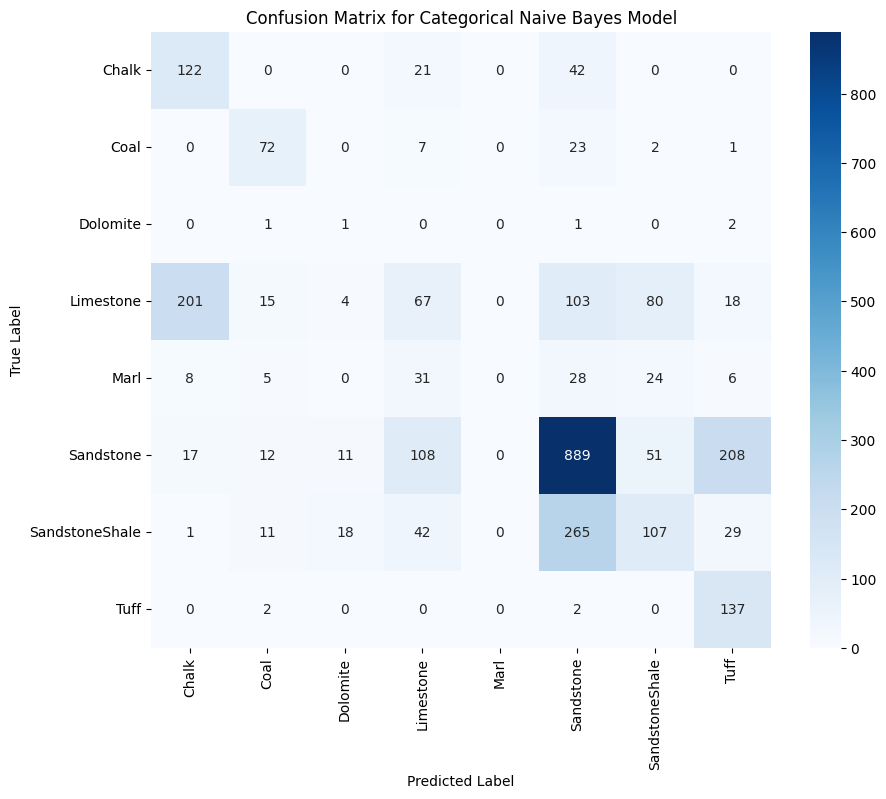

In [9]:
# Plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Create confusion matrix
cm = confusion_matrix(Testing_C_Label, Predictions_C, labels=My_CNB_Model.classes_)
# Plotting the confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=My_CNB_Model.classes_,
            yticklabels=My_CNB_Model.classes_)
plt.title('Confusion Matrix for Categorical Naive Bayes Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Multinomial NB

In [10]:
multinomial_df = pd.read_csv("data/nb/mnb_data.csv")

multinomial_df = categorical_df.copy()
# Train test splitting
Training_MN, Testing_MN = train_test_split(multinomial_df, test_size=.2)
##  Save the Labels and then remove them from the Training and Testing data
Training_MN_Label = Training_MN["LITHOLOGY"]
Training_MN=Training_MN.drop(["LITHOLOGY"], axis=1)
Testing_MN_Label = Testing_MN["LITHOLOGY"]
Testing_MN=Testing_MN.drop(["LITHOLOGY"], axis=1)

display(Testing_MN.head(3))
Testing_MN_Label.head(3)

,CALI,RHOB,NPHI,DTC
2101,1.0,1.0,0.0,0.0
130,1.0,1.0,1.0,1.0
1896,1.0,2.0,0.0,0.0


2101    Limestone
130     Limestone
1896        Chalk
Name: LITHOLOGY, dtype: object

In [17]:
from sklearn.naive_bayes import MultinomialNB

MyMN = MultinomialNB()
display(Training_MN.head(10))
display(Training_MN_Label.head(10))
Training_MN.to_csv("data/nb/mnb_train.csv")
Training_MN_Label.to_csv("data/nb/mnb_train_labels.csv")
Testing_MN.to_csv("data/nb/mnb_test.csv")
Testing_MN_Label.to_csv("data/nb/mnb_test_labels.csv")
## Traing the model
My_MN_Model = MyMN.fit(Training_MN, Training_MN_Label)
print(My_MN_Model)
print(My_MN_Model.classes_)

## Predict the Testing Data using the model
Predictions_MN=My_MN_Model.predict(Testing_MN)
print(Predictions_MN)

## Print the actual probabilities
print("\n\nThe Multinomial NB Model Prediction Probabilities are:")
print(My_MN_Model.predict_proba(Testing_MN).round(3))

,CALI,RHOB,NPHI,DTC
4917,0.0,1.0,0.0,1.0
9287,0.0,2.0,0.0,1.0
1483,1.0,2.0,0.0,0.0
5598,0.0,1.0,0.0,1.0
12339,0.0,1.0,0.0,1.0
10234,1.0,1.0,1.0,1.0
11036,1.0,1.0,0.0,1.0
5107,0.0,1.0,0.0,1.0
1061,1.0,2.0,0.0,0.0
11542,1.0,2.0,0.0,0.0


4917     SandstoneShale
9287          Limestone
1483              Chalk
5598          Sandstone
12339         Sandstone
10234              Tuff
11036         Sandstone
5107     SandstoneShale
1061          Limestone
11542         Limestone
Name: LITHOLOGY, dtype: object

MultinomialNB()
['Chalk' 'Coal' 'Dolomite' 'Limestone' 'Marl' 'Sandstone' 'SandstoneShale'
 'Tuff']
['Sandstone' 'Sandstone' 'Limestone' ... 'Sandstone' 'Sandstone'
 'Sandstone']


The Multinomial NB Model Prediction Probabilities are:
[[0.167 0.01  0.002 ... 0.384 0.074 0.036]
 [0.    0.064 0.007 ... 0.563 0.126 0.13 ]
 [0.213 0.002 0.001 ... 0.32  0.07  0.017]
 ...
 [0.121 0.002 0.    ... 0.361 0.176 0.013]
 [0.008 0.011 0.001 ... 0.541 0.251 0.025]
 [0.011 0.003 0.    ... 0.499 0.264 0.013]]


In [42]:
# Calculate the accuracy of the model
mnb_accuracy = My_MN_Model.score(Testing_MN, Testing_MN_Label)
print("The accuracy of the Multinomial Naive Bayes model is: ", mnb_accuracy)

The accuracy of the Multinomial Naive Bayes model is:  0.526654740608229


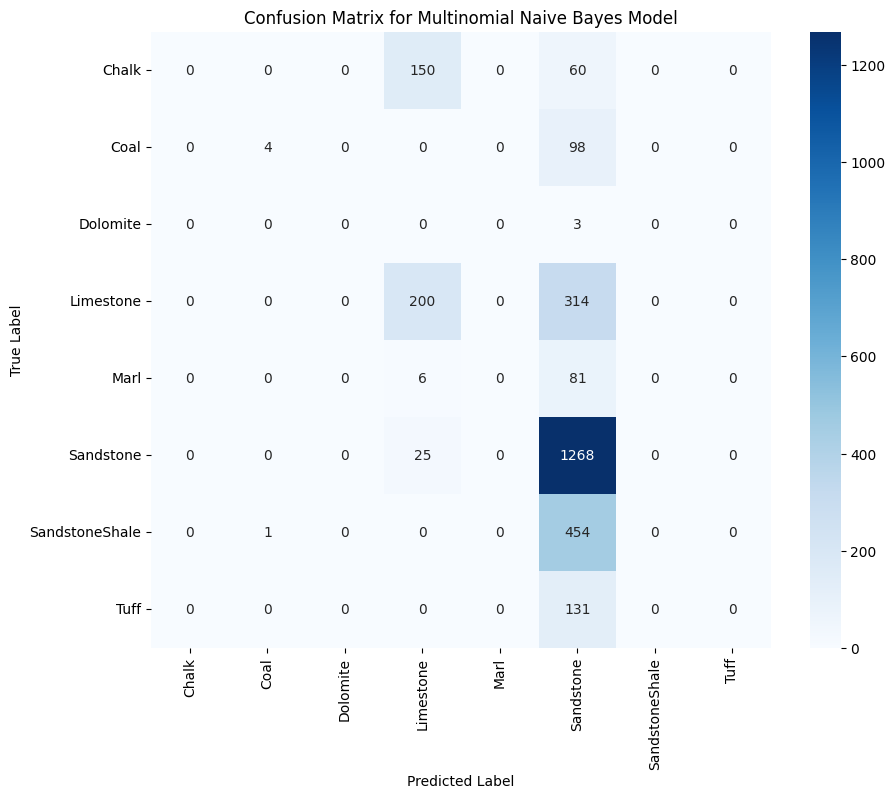

In [12]:
# Plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Create confusion matrix
cm = confusion_matrix(Testing_MN_Label, Predictions_MN, labels=My_MN_Model.classes_)
# Plotting the confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=My_MN_Model.classes_,
            yticklabels=My_MN_Model.classes_)
plt.title('Confusion Matrix for Multinomial Naive Bayes Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Evaluation

In [13]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, classification_report, confusion_matrix
import numpy as np

def evaluate_multiclass_model(y_true, y_pred, y_proba, average='weighted'):
    """
    Evaluate a multi-class classification model with imbalanced data.
    
    Parameters:
    - y_true : array-like, true class labels
    - y_pred : array-like, predicted class labels
    - y_proba: array-like, predicted probability for each class
    - average: str, averaging method for multi-class metrics ('macro', 'micro', 'weighted')

    Returns:
    - A dictionary containing accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC scores.
    """
    metrics = {}

    # Accuracy
    metrics["Accuracy"] = accuracy_score(y_true, y_pred)

    # Precision, Recall, F1-Score
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=average)
    metrics["Precision"] = precision
    metrics["Recall"] = recall
    metrics["F1-Score"] = f1

    # ROC-AUC Score (only works if y_proba is available)
    try:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average=average)
    except:
        metrics["ROC-AUC"] = "N/A (Check y_proba format)"

    # Print classification report
    print("Classification Report:\n", classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)

    return metrics

##### Gaussian NV model evaluation

In [14]:
g_results = evaluate_multiclass_model(Testing_G_Label, Predictions_G, MyGNB_Model.predict_proba(Testing_G))


Classification Report:
                 precision    recall  f1-score   support

         Chalk       0.35      0.90      0.51       186
          Coal       0.35      0.63      0.45        94
      Dolomite       0.10      0.60      0.17         5
     Limestone       0.31      0.18      0.23       476
          Marl       0.19      0.03      0.06        88
     Sandstone       0.68      0.81      0.74      1307
SandstoneShale       0.73      0.08      0.15       493
          Tuff       0.63      0.90      0.74       146

      accuracy                           0.55      2795
     macro avg       0.42      0.52      0.38      2795
  weighted avg       0.57      0.55      0.50      2795

Confusion Matrix:
 [[ 168    0    0   18    0    0    0    0]
 [   0   59    0    0    0   33    2    0]
 [   0    0    3    0    0    1    0    1]
 [ 236   16    9   86    0  110    5   14]
 [  26    6    0   19    3   34    0    0]
 [  44   58   10   84    7 1055    8   41]
 [   3   23    7   74   

##### Categorical NB model evaluation

In [51]:
c_results = evaluate_multiclass_model(Testing_C_Label, Predictions_C, MyCNB.predict_proba(Testing_C))

Classification Report:
                 precision    recall  f1-score   support

         Chalk       0.35      0.66      0.46       185
          Coal       0.61      0.69      0.65       105
      Dolomite       0.03      0.20      0.05         5
     Limestone       0.24      0.14      0.18       488
          Marl       0.00      0.00      0.00       102
     Sandstone       0.66      0.69      0.67      1296
SandstoneShale       0.41      0.23      0.29       473
          Tuff       0.34      0.97      0.51       141

      accuracy                           0.50      2795
     macro avg       0.33      0.45      0.35      2795
  weighted avg       0.48      0.50      0.47      2795

Confusion Matrix:
 [[122   0   0  21   0  42   0   0]
 [  0  72   0   7   0  23   2   1]
 [  0   1   1   0   0   1   0   2]
 [201  15   4  67   0 103  80  18]
 [  8   5   0  31   0  28  24   6]
 [ 17  12  11 108   0 889  51 208]
 [  1  11  18  42   0 265 107  29]
 [  0   2   0   0   0   2   0 137]]


/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

##### Multinomial NB model evaluation

In [16]:
# Multinomial NB model evaluation
mn_results = evaluate_multiclass_model(
    y_true=Testing_MN_Label,
    y_pred=Predictions_MN,
    y_proba=My_MN_Model.predict_proba(Testing_MN),
    average='weighted'
)
print(mn_results)

Classification Report:
                 precision    recall  f1-score   support

         Chalk       0.00      0.00      0.00       210
          Coal       0.80      0.04      0.07       102
      Dolomite       0.00      0.00      0.00         3
     Limestone       0.52      0.39      0.45       514
          Marl       0.00      0.00      0.00        87
     Sandstone       0.53      0.98      0.69      1293
SandstoneShale       0.00      0.00      0.00       455
          Tuff       0.00      0.00      0.00       131

      accuracy                           0.53      2795
     macro avg       0.23      0.18      0.15      2795
  weighted avg       0.37      0.53      0.40      2795

Confusion Matrix:
 [[   0    0    0  150    0   60    0    0]
 [   0    4    0    0    0   98    0    0]
 [   0    0    0    0    0    3    0    0]
 [   0    0    0  200    0  314    0    0]
 [   0    0    0    6    0   81    0    0]
 [   0    0    0   25    0 1268    0    0]
 [   0    1    0    0   

/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

### Train-test split plot

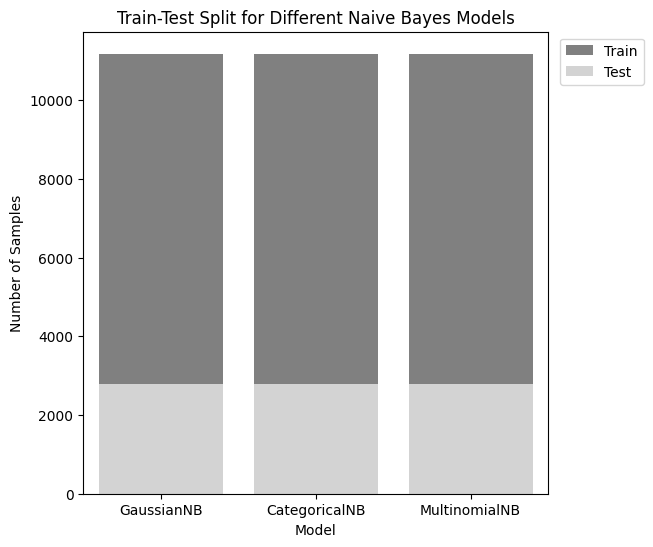

In [39]:
# Bar plot of train - test ratio data
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame with the data
data = {
    'Model': ['GaussianNB', 'CategoricalNB', 'MultinomialNB'],
    'Test': [len(Testing_G), len(Testing_C), len(Testing_MN)],
    'Train': [len(Training_G), len(Training_C), len(Training_MN)],
}

df_plot = pd.DataFrame(data)

# Set the figure size
plt.figure(figsize=(6, 6))

# Create a bar plot
sns.barplot(x='Model', y='Train', data=df_plot, color='grey', label='Train')
sns.barplot(x='Model', y='Test', data=df_plot, color='lightgrey', label='Test')

# Add labels and title
plt.xlabel('Model')
plt.ylabel('Number of Samples')
plt.title('Train-Test Split for Different Naive Bayes Models')
plt.legend(loc='upper right', bbox_to_anchor=(1.22, 1))
plt.show()

#### Accuracy plot

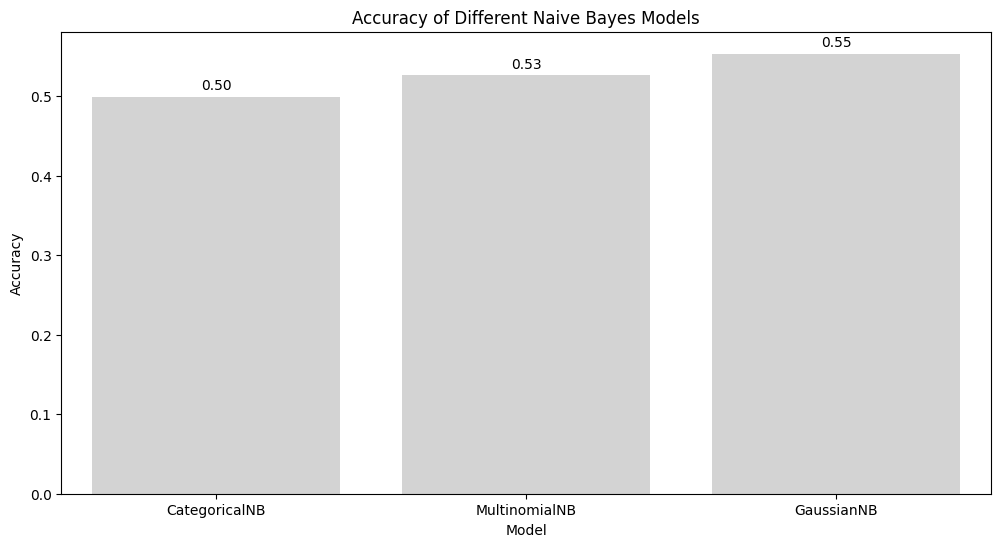

In [48]:
# Plot accuracy of the models
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame with the data
data = {
    'Model': ['GaussianNB', 'CategoricalNB', 'MultinomialNB'],
    'Accuracy': [gnb_accuracy, cnb_accuracy, mnb_accuracy],
}

df_plot = pd.DataFrame(data)
# Sort ascending
df_plot = df_plot.sort_values(by='Accuracy', ascending=True)

# Set the figure size
plt.figure(figsize=(12, 6))

# Create a bar plot
barplot = sns.barplot(x='Model', y='Accuracy', data=df_plot, color='lightgrey')

# Add values on top of the bars
for bar in barplot.patches:
    barplot.annotate(format(bar.get_height(), '.2f'),
                     (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                     ha='center', va='center', size=10, xytext=(0, 8),
                     textcoords='offset points')

# Add labels and title
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy of Different Naive Bayes Models')

# Show the plot
plt.show()

#### Backup

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.exceptions import UndefinedMetricWarning

# Suppress UndefinedMetricWarning
import warnings
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
def classification_report_plot(title, labels, predictions):
    # Generate the classification report as a dictionary
    report = classification_report(labels, predictions, output_dict=True)

    # Convert the report dictionary to a pandas DataFrame
    report_df = pd.DataFrame(report).transpose()
    report_df.columns = ['Precision', 'Recall', 'F1-Score', 'Support']

    # Plot the classification report as a heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(report_df.iloc[:-4, :-1], annot=True, cmap="YlGnBu", fmt=".2f", cbar=False)

    # Add labels and title
    plt.title(f"{title} - Classification Report")
    plt.xlabel("Metrics")
    plt.ylabel("Lithology", labelpad=20)
    plt.gca().xaxis.set_label_position("top")
    plt.gca().xaxis.tick_top()
    plt.show()

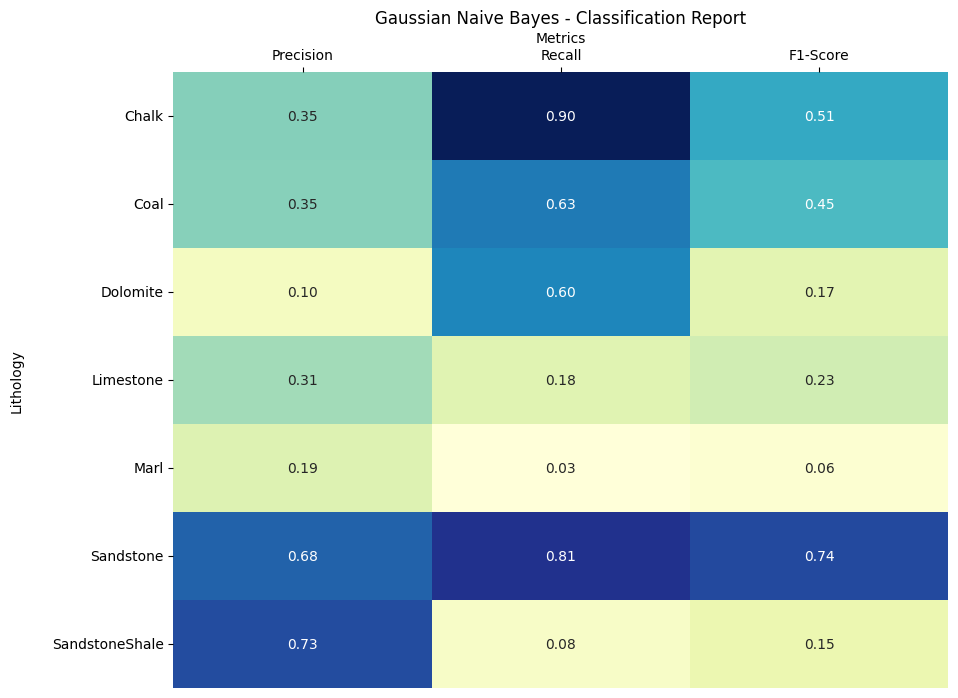

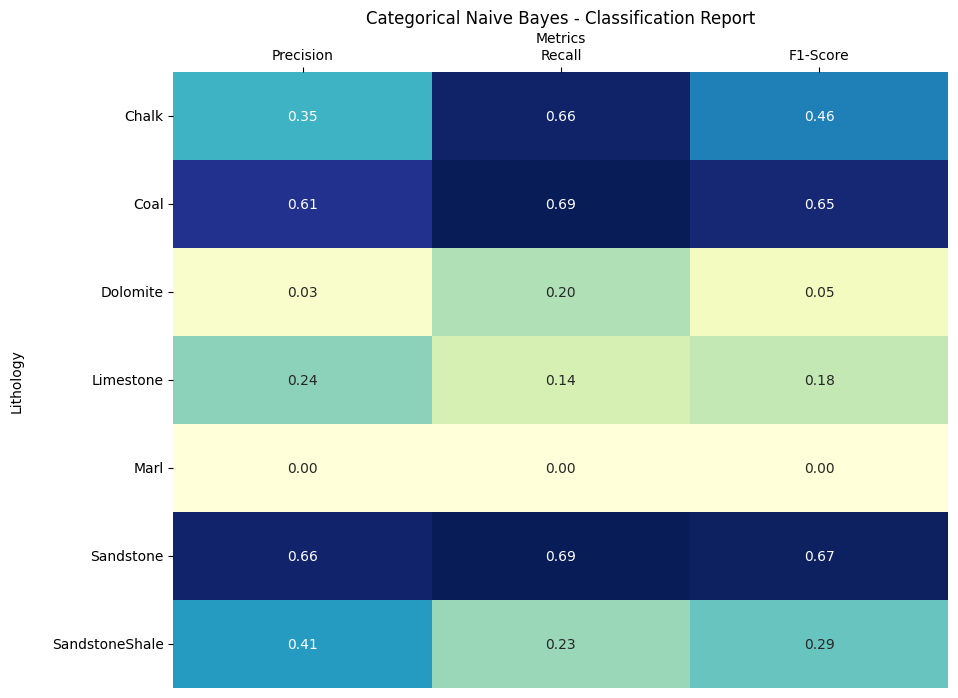

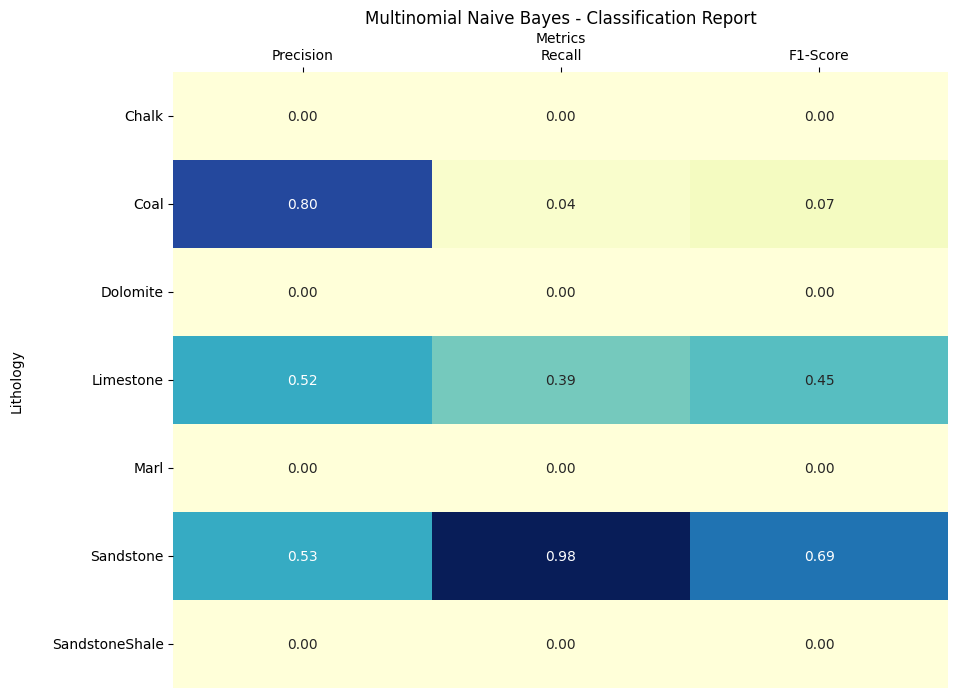

In [66]:
# Gaussion classification report
classification_report_plot("Gaussian Naive Bayes", Testing_G_Label, Predictions_G)

# Categorical classification report
classification_report_plot("Categorical Naive Bayes", Testing_C_Label, Predictions_C)

# Multinomial classification report
classification_report_plot("Multinomial Naive Bayes", Testing_MN_Label, Predictions_MN)